In [1]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV , RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
credit_data=fetch_openml(name='credit-g',version=1,as_frame=True,parser='auto')
df= credit_data.frame

In [3]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [4]:
df['class']=df['class'].map({'good':1 ,'bad':0})

In [5]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,1
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,0
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,1
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,1
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,0


In [6]:
df.shape

(1000, 21)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

In [8]:
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [9]:
df.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

In [10]:
X=df.drop('class',axis=1)
y=df['class']

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=15,test_size=0.2)

In [12]:
numerical = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical = X.select_dtypes(include=['category', 'object']).columns

In [13]:
print(categorical)

Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker'],
      dtype='object')


In [14]:
print(numerical)

['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']


In [15]:
df['class'].value_counts()

class
1    700
0    300
Name: count, dtype: int64

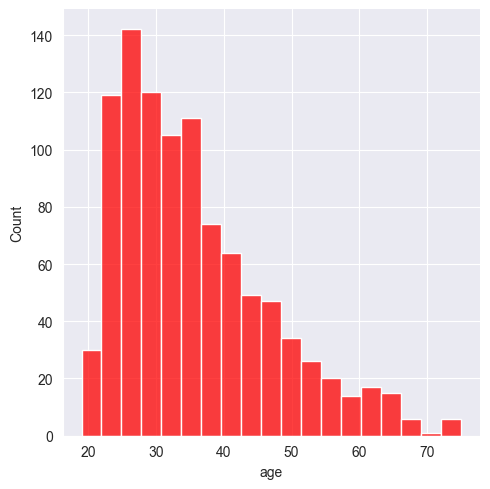

In [16]:
sns.displot(df['age'], color='red')
plt.show()

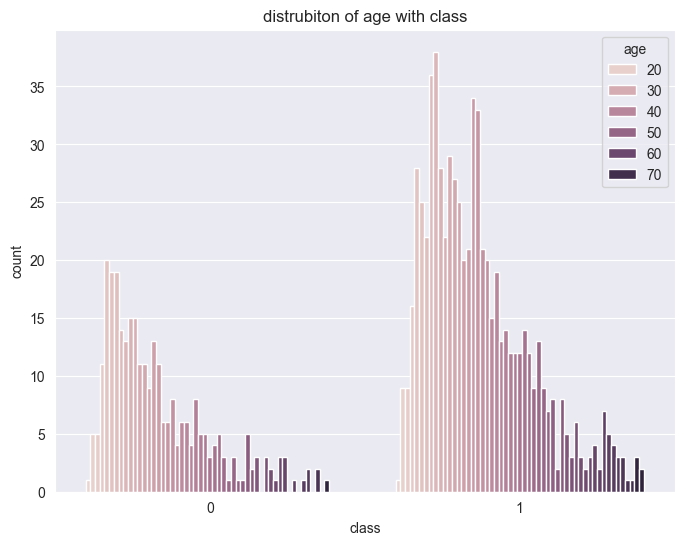

In [17]:
fig, ax = plt.subplots(figsize=(8,6))
ax= sns.countplot(data=df,hue='age',x='class')
ax.set_title('distrubiton of age with class')
plt.show()

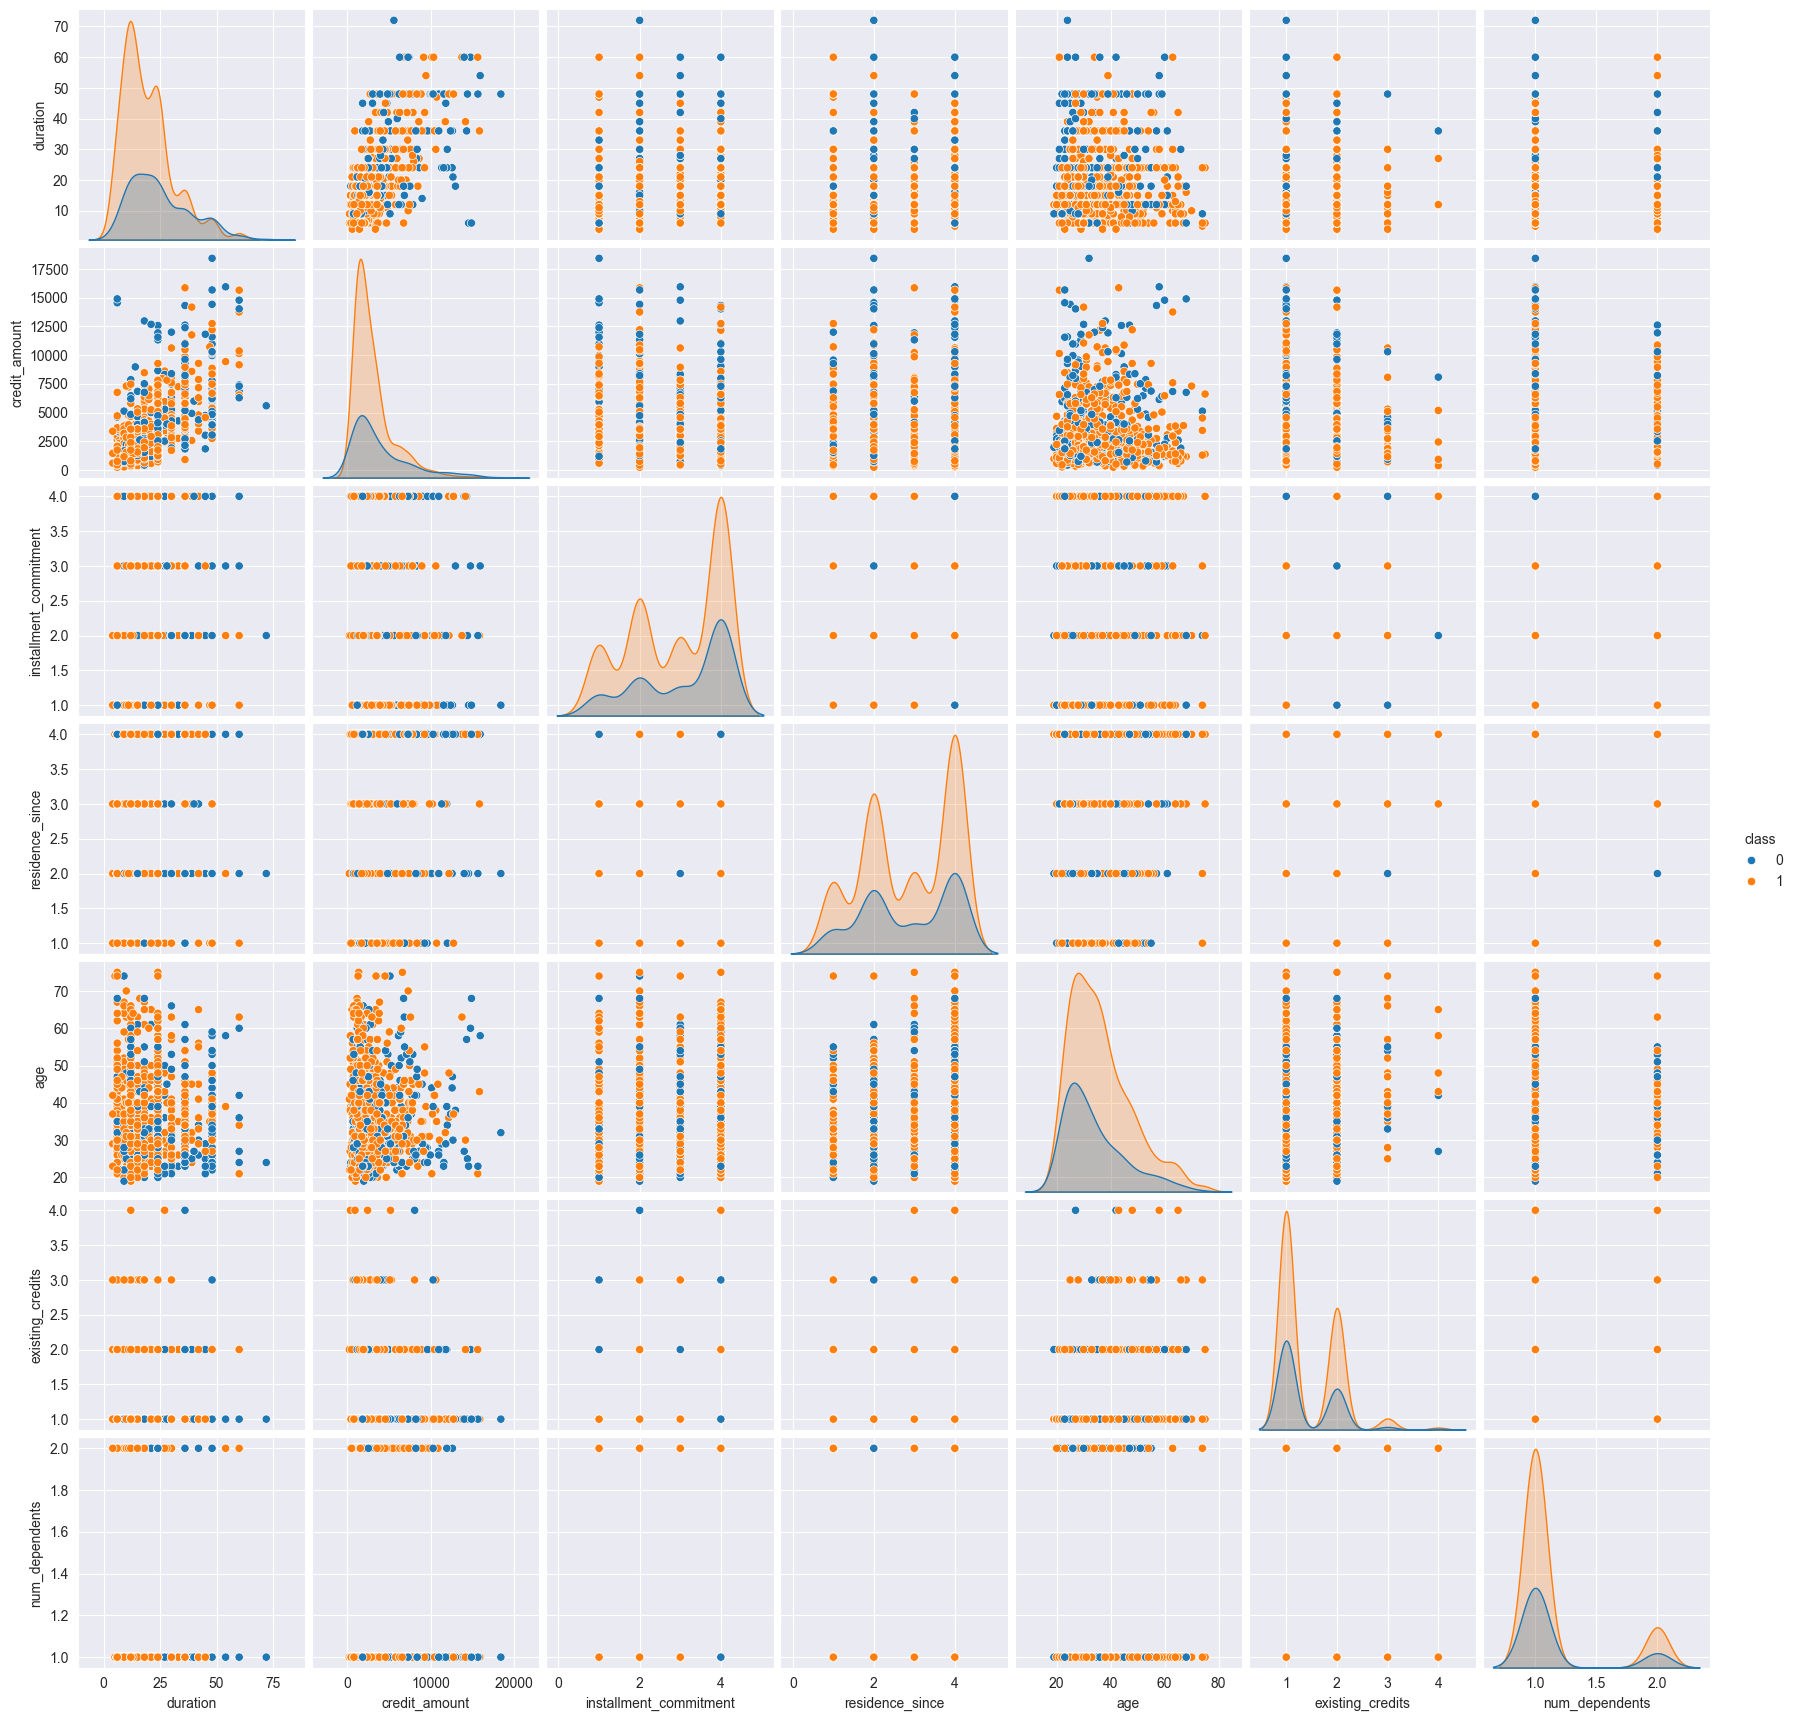

In [18]:
sns.pairplot(df,hue='class')
plt.show()

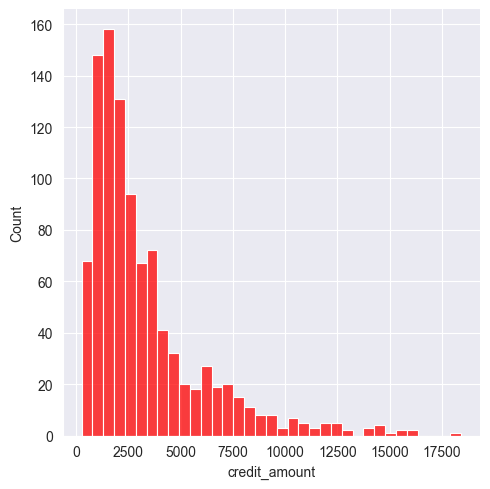

In [19]:
sns.displot(df['credit_amount'], color='red')
plt.show()

In [20]:
for col in df.columns:
    print(df[col].unique)

<bound method Series.unique of 0               <0
1         0<=X<200
2      no checking
3               <0
4               <0
          ...     
995    no checking
996             <0
997    no checking
998             <0
999       0<=X<200
Name: checking_status, Length: 1000, dtype: category
Categories (4, object): ['0<=X<200', '<0', '>=200', 'no checking']>
<bound method Series.unique of 0       6
1      48
2      12
3      42
4      24
       ..
995    12
996    30
997    12
998    45
999    45
Name: duration, Length: 1000, dtype: int64>
<bound method Series.unique of 0      critical/other existing credit
1                       existing paid
2      critical/other existing credit
3                       existing paid
4                  delayed previously
                    ...              
995                     existing paid
996                     existing paid
997                     existing paid
998                     existing paid
999    critical/other existing credit
Name:

In [21]:
numerical_transformer=StandardScaler()

In [22]:
categorical_transformer=OneHotEncoder(handle_unknown='ignore')

In [23]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',numerical_transformer,numerical),
        ('cat',categorical_transformer,categorical)
    ]
)

In [24]:
rfc_pipe=Pipeline(
    [
        ('preprocessor',preprocessor),
        ('classifier',RandomForestClassifier(random_state=15))
    ]
)

In [25]:
param_grid= {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, None]
}

In [26]:
randomized_search=RandomizedSearchCV(estimator=rfc_pipe,param_distributions=param_grid,n_iter=10,cv=3,verbose=2,n_jobs=-1)
randomized_search.fit(X_train,y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


C:\Users\Monster\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...m_state=15))])
,param_distributions,"{'classifier__max_depth': [5, 10, ...], 'classifier__n_estimators': [50, 100, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [27]:
randomized_search.best_params_

{'classifier__n_estimators': 200, 'classifier__max_depth': None}

In [28]:
randomized_search.best_score_

np.float64(0.7887555968573118)

In [29]:

y_pred=randomized_search.predict(X_test)

In [30]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.76
[[ 18  36]
 [ 12 134]]
              precision    recall  f1-score   support

           0       0.60      0.33      0.43        54
           1       0.79      0.92      0.85       146

    accuracy                           0.76       200
   macro avg       0.69      0.63      0.64       200
weighted avg       0.74      0.76      0.73       200



In [31]:
best_model=randomized_search.best_estimator_

In [32]:
rf_classifier=best_model.named_steps['classifier']

In [33]:
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features_new = cat_encoder.get_feature_names_out(categorical)
all_features = list(numerical) + list(cat_features_new)

In [34]:
importances=rf_classifier.feature_importances_

In [35]:
importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

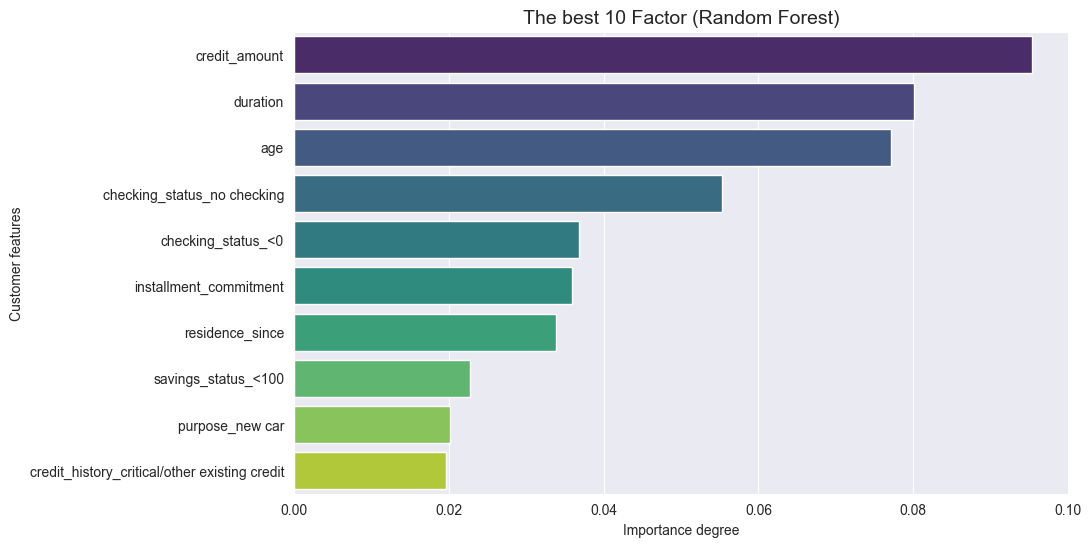